In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm
from factor_model import *
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
from scenario_generator import *
import numpy as np

_exp = "stable"
PREFIX = f"model/{_exp}"
with open(f"{PREFIX}/cfg.yaml") as f:
    _cfg = yaml.safe_load(f)

FACTOR_NAMES = _cfg["factors"]
NUM_GENERATE = _cfg["num_generate"]
CKPT_PATH = f"{PREFIX}/checkpoints/{_cfg['ckpt_name']}.pt"

/home/renyi/anaconda3/envs/diffusion_factor_model/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_TIMESTEPS = _cfg["num_timesteps"]
LEVY_ALPHA    = _cfg["levy_alpha"]
BATCH_SIZE    = _cfg["batch_size"]
FACTOR_DIM    = len(_cfg["factors"])
CHECKPOINT    = f"{PREFIX}/checkpoints/{_cfg['ckpt_name']}.pt"
print(CHECKPOINT)

model/stable/checkpoints/DDPM_vanilla.pt


In [4]:
test_model = load_model(f"{PREFIX}/test")
train_model = load_model(f"{PREFIX}")
test_factor = test_model.F
test_factor.drop(columns=["alpha"], inplace=True)
oos_factor_np = test_factor.to_numpy()
oos_factor_np.shape

(260, 7)

In [5]:
diffusionScenario = ScenarioGenerator(test_model, DiffusionSampler(CHECKPOINT, DEVICE))
scaler = diffusionScenario.sampler.scaler

/home/renyi/anaconda3/envs/diffusion_factor_model/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [6]:
cond_name   = "value"
frac        = -0.3
feature_idx = FACTOR_NAMES.index(cond_name)

target_raw  = oos_factor_np[:, feature_idx] * (1 + frac)          # (T_oos,)

_dummy = np.zeros((len(target_raw), FACTOR_DIM))
_dummy[:, feature_idx] = target_raw
target_norm = scaler.transform(_dummy)[:, feature_idx]            # (T_oos,)
target_norm = torch.as_tensor(target_norm, dtype=torch.float32, device=DEVICE)

diffusionScenario.sampler.cfg["batch_size"] = len(oos_factor_np)

def cond_fn(x0_hat):
    return (x0_hat[:, feature_idx] - target_norm) ** 2



In [7]:
# guidance_scale defaults to 1.0 (too weak -> cap barely binds); strength=0.6 re-rolls too
# much of each day. Raise guidance, lower strength so the edit stays close to the observed
# day and only pushes value down. Re-run the sanity-check cell below and read the obs>0 / obs<0
# split: obs>0 sat% should climb toward ~100%, obs<0 should stay near its 100% baseline.
diffusionScenario.sampler.guidance_scale = 30.0
cf_factors, cf_returns = diffusionScenario.style_transfer_oos(oos_factor_np, cond_fn, strength=0.3)

In [8]:
cf_factors.shape

(260, 7)

In [15]:
return_df = returns_to_panel(test_model, generated_returns=cf_returns)
return_df.to_parquet("value-30.parquet", index=False)

In [8]:
# ---- factor-level scorecard (what the model actually generates; no recon noise, no beta amp) ----
# GOOD style transfer = value moves DOWN, every other factor stays close to its observed day:
#   std_ratio ~1 (marginal preserved), move/std small-ish (didn't drift far), corr->value kept.
K    = oos_factor_np.shape[1]
Cobs = np.corrcoef(oos_factor_np, rowvar=False)
Ccf  = np.corrcoef(cf_factors,    rowvar=False)
print(f"{'factor':<11}{'mean obs -> cf':>22}   std_ratio  move/std   corr->value obs->cf")
for i, name in enumerate(FACTOR_NAMES):
    std_i    = oos_factor_np[:, i].std()
    ratio    = cf_factors[:, i].std() / std_i
    rel_move = np.abs(cf_factors[:, i] - oos_factor_np[:, i]).mean() / std_i
    cv_o, cv_c = Cobs[i, feature_idx], Ccf[i, feature_idx]
    tag = "  <-- target" if i == feature_idx else ""
    print(f"  {name:<9}{oos_factor_np[:,i].mean():+.5f} -> {cf_factors[:,i].mean():+.5f}"
          f"     {ratio:4.2f}      {rel_move:4.2f}     {cv_o:+.2f} -> {cv_c:+.2f}{tag}")

off = ~np.eye(K, dtype=bool)
print(f"\nfactor corr  Frobenius(obs,cf) {np.linalg.norm(Cobs - Ccf):.3f}"
      f"   |off-diag| mean {np.abs(Cobs[off]).mean():.3f} -> {np.abs(Ccf[off]).mean():.3f}")


factor             mean obs -> cf   std_ratio  move/std   corr->value obs->cf
  market   +0.00032 -> +0.00065     1.13      0.59     +0.22 -> +0.24
  growth   -0.00007 -> -0.00004     1.02      0.58     +0.08 -> +0.04
  momentum +0.00024 -> +0.00025     0.88      0.58     -0.09 -> -0.08
  quality  +0.00002 -> +0.00005     0.99      0.57     +0.37 -> +0.33
  size     +0.00005 -> +0.00013     0.94      0.36     +0.41 -> +0.39
  value    +0.00044 -> +0.00032     0.72      0.23     +1.00 -> +1.00  <-- target
  volatility-0.00030 -> -0.00032     0.93      0.45     +0.01 -> -0.01

factor corr  Frobenius(obs,cf) 0.529   |off-diag| mean 0.186 -> 0.176


In [9]:
# ---- inverse of get_factor_model: write cf_returns back into the long panel ----
from factor_model import returns_to_panel

src  = pd.read_parquet(test_model.data_source)           # original test panel (date, csecid, returns, *features)
sids = test_model.stock_ids or sorted(src["csecid"].unique())

panel_cf = returns_to_panel(
    test_model, cf_returns,
    factor_dates=test_model.F.index,   # rows of cf_returns align to OOS factor dates
    source_df=src,
    shift=True,                        # factor_t -> return written at next panel date
    only_filled=True,                  # just the overwritten (date, csecid) rows; drop for full panel
)
print(f"source panel  {src.shape}   cols {list(src.columns)}")
print(f"refilled rows {panel_cf.shape}   (cf cells = {cf_returns.shape[0]*cf_returns.shape[1]})")

# round-trip check: pivot the refilled returns back and compare against cf_returns
dates_sorted = sorted(src["date"].unique())
nxt = {dates_sorted[i]: dates_sorted[i+1] for i in range(len(dates_sorted)-1)}
ret_dates = [nxt[d] for d in test_model.F.index]
chk = (panel_cf.pivot_table(index="date", columns="csecid", values="returns")
       .reindex(index=ret_dates, columns=sids))
print(f"max |refilled - cf_returns| (where panel has the row): {np.nanmax(np.abs(chk.values - cf_returns)):.2e}")
feat_cols = lambda d: [c for c in d.columns if c not in ("date", "csecid", "returns")]
print(f"feature cols identical to source: {feat_cols(src) == feat_cols(panel_cf)}")
panel_cf.head()


source panel  (486664, 12)   cols ['date', 'csecid', 'returns', 'growth', 'momentum', 'quality', 'size', 'value', 'volatility', 'mcap', 'gics', 'region']
refilled rows (484772, 12)   (cf cells = 514540)
max |refilled - cf_returns| (where panel has the row): 0.00e+00
feature cols identical to source: True


,date,csecid,returns,growth,momentum,quality,size,value,volatility,mcap,gics,region
0,2025-01-02,70011129,-0.001638,0.377918,-0.488918,-1.466277,0.521991,1.526769,0.076279,-0.606752,20.0,3.0
1,2025-01-02,70012234,0.007612,-0.199898,-0.116347,0.203055,0.967980,0.989847,1.710325,-1.091079,20.0,3.0
2,2025-01-02,70012564,0.014340,1.635667,1.012513,-0.884463,-0.412029,-0.814383,0.684971,0.407557,25.0,2.0
3,2025-01-02,70021576,0.021741,-0.627547,-0.917808,-2.893246,1.132093,-0.082819,-1.305380,-1.269299,50.0,2.0
4,2025-01-02,70021617,-0.016397,-0.749676,0.572145,-0.092579,-1.079298,-0.217810,0.750519,1.132184,55.0,1.0


In [10]:
COLORS = {
    "uncon":     "#888888",
    "con":       "#2196F3",
    "rej":       "#FF5722",
    "gaussion":  "#4CAF50",
    "train":     "#FFC107"
}

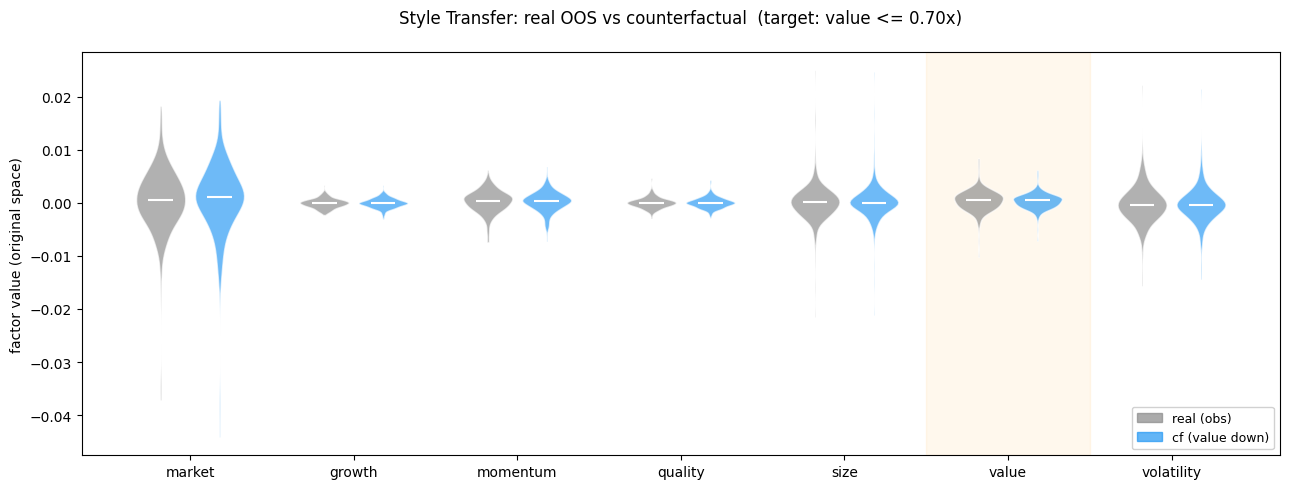

In [11]:
datasets = [
    ("real (obs)",  oos_factor_np, COLORS["uncon"]),
    ("cf (value down)", cf_factors, COLORS["con"]),
]
x_center = np.arange(FACTOR_DIM)
offsets  = [-0.18, 0.18]
fig, ax = plt.subplots(figsize=(13, 5))

for offset, (label, data, color) in zip(offsets, datasets):
    parts = ax.violinplot(
        [data[:, i] for i in range(FACTOR_DIM)],
        positions=x_center + offset,
        widths=0.30,
        showmedians=True,
        showextrema=False,
    )
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_edgecolor("white")
        pc.set_alpha(0.65)
    parts["cmedians"].set_color("white")
    parts["cmedians"].set_linewidth(1.5)

# mark the targeted factor
ax.axvspan(feature_idx - 0.5, feature_idx + 0.5, color="orange", alpha=0.07, zorder=0)

ax.set_xticks(x_center)
ax.set_xticklabels(FACTOR_NAMES, fontsize=10)
ax.set_ylabel("factor value (original space)")
ax.set_title(
    f"Style Transfer: real OOS vs counterfactual  (target: {cond_name} <= {1+frac:.2f}x)\n"
)

handles = [mpatches.Patch(color=c, alpha=0.7, label=l) for l, _, c in datasets]
ax.legend(handles=handles, fontsize=9, framealpha=0.9)

fig.tight_layout()
plt.show()